In [ ]:
import random
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import gymnasium as gym

In [11]:
env = gym.make("Taxi-v3")

n_stats = env.observation_space.n #  25 taxi positions, 5 possible locations of the passenger (including the case when the passenger is in the taxi), and 4 destination locations.
n_actions = env.action_space.n # the range {0, 5} indicating which direction to move the taxi or to pickup/drop off passengers.
print("n_stats = ", n_stats)
print("n_actions = ", n_actions)


n_stats =  500
n_actions =  6


In [12]:
## parameters init
GAMMA = 0.9
ALPHA = 0.9
EPSILON = 0.9
EPSILON_f = 0.1
EPSILON_decay = 0.99

In [17]:
Q = defaultdict(lambda: np.zeros(n_actions)) # 
n_episodes = 1000

scores = []
steps = []
greedy = []

for episode in range(n_episodes):

    if episode > 980:
        env = gym.make("Taxi-v3", render_mode = "human")
    if EPSILON > EPSILON_f:
        EPSILON *= EPSILON_decay

    s, _ = env.reset()
    step = 0
    score = 0
    
    while True:
        step += 1

        # e-greedy
        if np.random.rand(1) < EPSILON:
            a = env.action_space.sample()
        else:
            a = np.argmax(Q[s])        

        s_, r, terminated, truncated, _ = env.step(a)
        score += r
        
        Q[s][a] = Q[s][a] + ALPHA*(r + GAMMA*np.max(Q[s_]) - Q[s][a]) #

        if terminated or truncated:
            break

        s = s_       
        
    scores.append(score)
    steps.append(step)
    greedy.append(EPSILON)

    if episode % 100 == 0:
        print("{}번째 episode: score = {}, step = {}".format(episode, score, step))

# pygame.quit()
env.close()

0번째 episode: score = -506, step = 200
100번째 episode: score = -44, step = 47
200번째 episode: score = -6, step = 27
300번째 episode: score = 9, step = 12
400번째 episode: score = 4, step = 17
500번째 episode: score = 3, step = 18
600번째 episode: score = 8, step = 13
700번째 episode: score = 6, step = 15
800번째 episode: score = 11, step = 10
900번째 episode: score = 5, step = 16


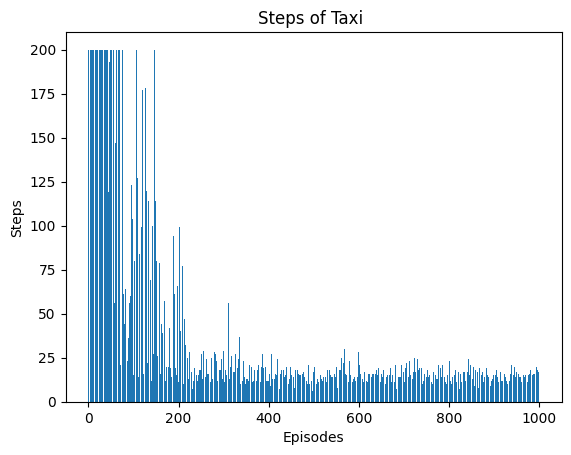

In [14]:
plt.bar(np.arange(len(steps)), steps)
plt.title("Steps of Taxi ")
plt.xlabel("Episodes")
plt.ylabel("Steps")
plt.show()

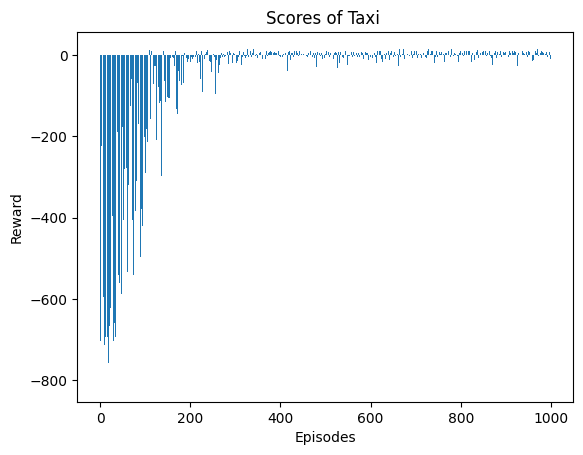

In [15]:
plt.bar(np.arange(len(scores)), scores)
plt.title("Scores of Taxi ")
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.show()

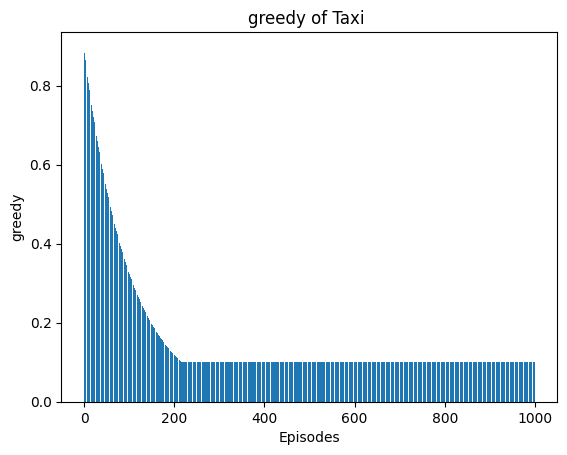

In [16]:
plt.bar(np.arange(len(greedy)), greedy)
plt.title("greedy of Taxi ")
plt.xlabel("Episodes")
plt.ylabel("greedy")
plt.show()

In [23]:
Q

defaultdict(<function __main__.<lambda>()>,
            {267: array([ -6.06292109,  -5.80573995,   1.62261432,  -6.07292437,
                    -11.358729  , -14.92207052]),
             367: array([ -6.10129376,  -5.77665368,   0.39488059,  -6.10583882,
                    -10.629     , -14.01340091]),
             467: array([ -6.10583882,  -5.76664949,  -6.12903592,  -6.10583882,
                     -9.        , -14.56312918]),
             167: array([-5.77803776,  2.9140163 ,  2.83039743, -0.15331614, -7.5396468 ,
                    -7.87946569]),
             287: array([-5.74550194,  2.9140163 , -5.58821254, -0.15309588, -9.        ,
                    -9.        ]),
             387: array([ -5.9339846 ,   1.62259502,  -0.15264328,  -5.54961873,
                    -13.52320722,  -9.        ]),
             487: array([ -6.14705405,  -0.33161683,  -6.20914813,  -6.13762733,
                     -9.        , -11.358729  ]),
             187: array([ -5.37552009,   4.348907  